Voice: финальная модель обучена на 195 записях
Spiral: финальная модель обучена на 102 изображениях
MRI: финальная модель обучена на 40 сканах
MoSVM обновлён — работает на честных моделях.

Все три модальности:


C:\Users\User\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


{'result': 'Healthy', 'score': 0.4023797322372097, 'modalities_used': ['voice', 'spiral', 'mri'], 'per_modality_prob': {'voice': np.float64(0.9973074144678231), 'spiral': np.float64(0.050654381590321554), 'mri': np.float64(0.3754438697330971)}}

MRI недоступна (voice+spiral):
{'result': 'Healthy', 'score': 0.4293155947413222, 'modalities_used': ['voice', 'spiral'], 'per_modality_prob': {'voice': np.float64(0.9973074144678231), 'spiral': np.float64(0.050654381590321554)}}


C:\Users\User\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


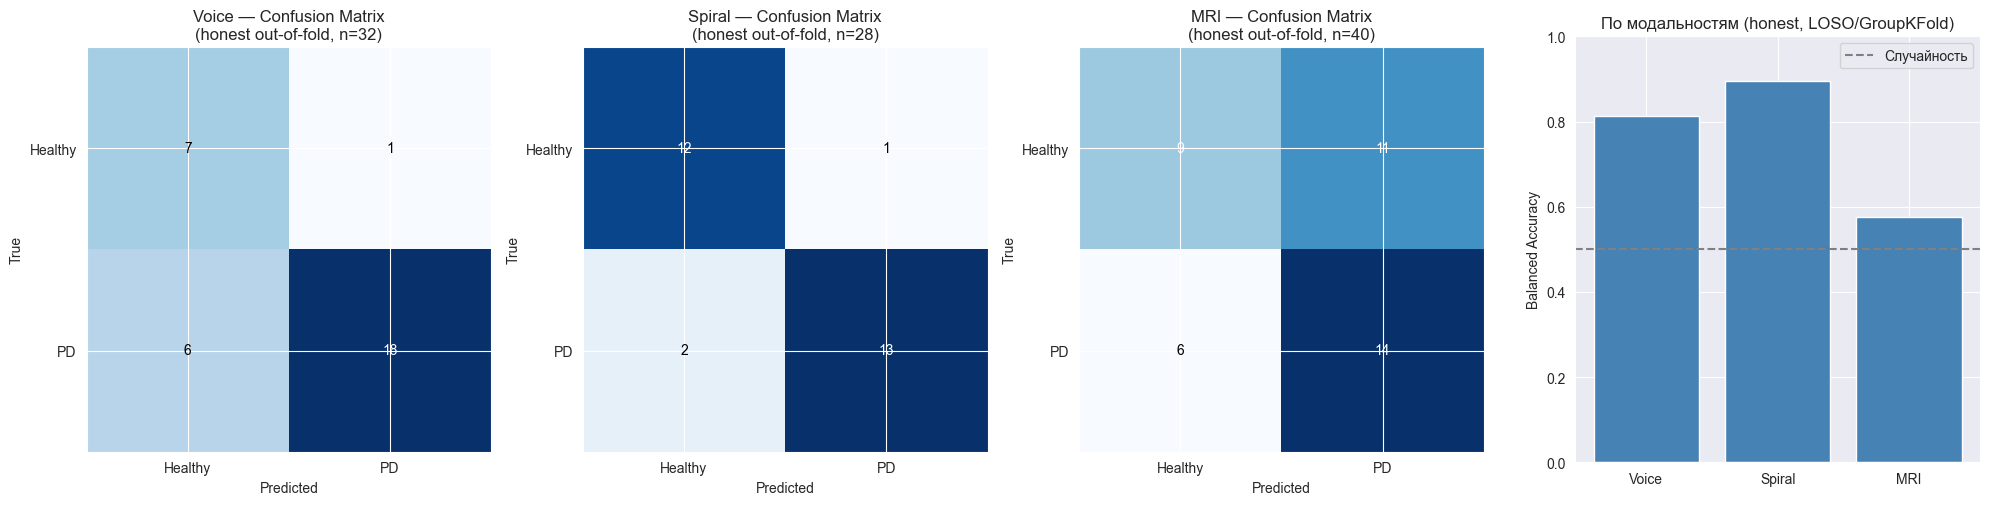

Сохранено: final_results_figure.png


In [1]:
import os, glob
import numpy as np
import pandas as pd
import nibabel as nib
from pathlib import Path
from PIL import Image
from scipy import ndimage
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing.image import img_to_array
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# ============================================================
# ЧАСТЬ 1 — ФИНАЛЬНЫЕ МОДЕЛИ (обучены на ВСЕХ данных, для деплоя)
# ============================================================

# --- Voice ---
df_voice = pd.read_csv('../../parkinsons.data')
X_voice = df_voice.drop(columns=['name', 'status'])
y_voice = df_voice['status'].values

pipe_voice = Pipeline([
    ('scaler', StandardScaler()),
    ('select', SelectKBest(f_classif, k=12)),
    ('svm', SVC(kernel='rbf', C=1.0, gamma='scale', probability=True,
                class_weight='balanced', random_state=42))
]).fit(X_voice, y_voice)
print("Voice: финальная модель обучена на", len(X_voice), "записях")

# --- Spiral ---
DATA_ROOT = Path("../parkinsons_drawings")
records = []
for split in ['training', 'testing']:
    for label_name in ['healthy', 'parkinson']:
        folder = DATA_ROOT / 'spiral' / split / label_name
        for img_path in folder.glob('*'):
            if img_path.suffix.lower() in ['.png', '.jpg', '.jpeg', '.bmp']:
                records.append({'path': str(img_path), 'label': 1 if label_name == 'parkinson' else 0})
df_spiral = pd.DataFrame(records)

mobilenet = MobileNetV2(weights='imagenet', include_top=False, pooling='avg', input_shape=(224, 224, 3))

def extract_mobilenet_features(path):
    img = Image.open(path).convert('RGB').resize((224, 224))
    arr = preprocess_input(img_to_array(img))
    return mobilenet.predict(np.expand_dims(arr, 0), verbose=0).flatten()

X_spiral = np.stack([extract_mobilenet_features(p) for p in df_spiral['path']])
y_spiral = df_spiral['label'].values

pipe_spiral = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=20, random_state=42)),
    ('svm', SVC(kernel='rbf', C=1.0, gamma='scale', probability=True,
                class_weight='balanced', random_state=42))
]).fit(X_spiral, y_spiral)
print("Spiral: финальная модель обучена на", len(X_spiral), "изображениях")

# --- MRI ---
TAOWU_PATH = '../taowu'
nii_files = sorted(glob.glob(os.path.join(TAOWU_PATH, 'sub-*/anat/*_T1w.nii.gz')))

def preprocess_nifti(filepath, target_shape=(128, 128, 128)):
    data = nib.load(filepath).get_fdata()
    data = ndimage.zoom(data, [t/s for t, s in zip(target_shape, data.shape)], order=1)
    return (data - np.mean(data)) / (np.std(data) + 1e-8)

def extract_mri_features(volume, n_slices=16):
    feats = [np.mean(volume), np.std(volume), np.median(volume),
             np.percentile(volume, 25), np.percentile(volume, 75), np.max(volume), np.min(volume)]
    hist, _ = np.histogram(volume.flatten(), bins=16, range=(-3, 3))
    feats.extend(hist)
    z = volume.shape[2]
    for idx in np.linspace(z//4, 3*z//4, n_slices).astype(int):
        s = volume[:, :, idx]
        feats.extend([np.mean(s), np.std(s), np.median(s)])
    return np.array(feats)

X_mri, y_mri = [], []
for f in nii_files:
    label = 0 if 'control' in os.path.basename(f) else 1
    X_mri.append(extract_mri_features(preprocess_nifti(f)))
    y_mri.append(label)
X_mri, y_mri = np.array(X_mri), np.array(y_mri)

pipe_mri = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=20, random_state=42)),
    ('svm', SVC(kernel='rbf', C=10, gamma='scale', probability=True, random_state=42))
    # C=10/rbf — самое частое сочетание среди best_params по фолдам; уточним в R2.3
]).fit(X_mri, y_mri)
print("MRI: финальная модель обучена на", len(X_mri), "сканах")

# ============================================================
# ЧАСТЬ 2 — MoSVM: система с поддержкой отсутствующих модальностей
# (использует финальные модели из Части 1, а не старые svm_* из
# feature_exctraction_images.ipynb)
# ============================================================

def intelligent_recognition_system(voice_data=None, spiral_path=None, mri_path=None, return_details=False):
    probabilities, weights, used = [], [], []

    if voice_data is not None:
        prob = pipe_voice.predict_proba(voice_data.reshape(1, -1))[0][1]
        probabilities.append(prob); weights.append(0.2); used.append('voice')

    if spiral_path is not None:
        feat = extract_mobilenet_features(spiral_path)
        prob = pipe_spiral.predict_proba(feat.reshape(1, -1))[0][1]
        probabilities.append(prob); weights.append(0.3); used.append('spiral')

    if mri_path is not None:
        vol = preprocess_nifti(mri_path)
        feat = extract_mri_features(vol)
        prob = pipe_mri.predict_proba(feat.reshape(1, -1))[0][1]
        probabilities.append(prob); weights.append(0.5); used.append('mri')

    if not probabilities:
        raise ValueError("Нужна хотя бы одна модальность")

    normalized_weights = np.array(weights) / sum(weights)
    final_score = float(np.dot(probabilities, normalized_weights))
    result = "Parkinson's Detected" if final_score > 0.5 else "Healthy"

    if return_details:
        return {'result': result, 'score': final_score, 'modalities_used': used,
                'per_modality_prob': dict(zip(used, probabilities))}
    return result

print("MoSVM обновлён — работает на честных моделях.")

# Демонстрация missing-modality tolerance (для R2.7): один и тот же случай,
# сначала со всеми тремя модальностями, потом с одной отсутствующей
example_voice = X_voice.iloc[0].values
example_spiral_path = df_spiral['path'].iloc[0]
example_mri_path = nii_files[0]

print("\nВсе три модальности:")
print(intelligent_recognition_system(example_voice, example_spiral_path, example_mri_path, return_details=True))
print("\nMRI недоступна (voice+spiral):")
print(intelligent_recognition_system(example_voice, example_spiral_path, None, return_details=True))

# ============================================================
# ЧАСТЬ 3 — ЧЕСТНАЯ ФИГУРА (замена старой fabricated cm/accuracies)
# считается по results_*.csv — реальным out-of-fold предсказаниям,
# НЕ по финальным моделям из Части 1
# ============================================================

results = {
    'Voice': pd.read_csv('results_voice.csv'),
    'Spiral': pd.read_csv('results_spiral.csv'),
    'MRI': pd.read_csv('results_mri.csv'),
}
ablation = pd.read_csv('ablation_fusion_table.csv')

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, (name, df_r) in zip(axes[:3], results.items()):
    cm = confusion_matrix(df_r['label'], df_r['pred'])
    ax.imshow(cm, cmap='Blues')
    ax.set_title(f'{name} — Confusion Matrix\n(honest out-of-fold, n={len(df_r)})')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(['Healthy', 'PD']); ax.set_yticklabels(['Healthy', 'PD'])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha='center', va='center',
                     color='white' if cm[i, j] > cm.max()/2 else 'black')

single = ablation[ablation['type'] == 'real (single modality)']
axes[3].bar(single['combination'], single['balanced_acc'].astype(float), color='steelblue')
axes[3].set_ylim(0, 1); axes[3].set_ylabel('Balanced Accuracy')
axes[3].set_title('По модальностям (honest, LOSO/GroupKFold)')
axes[3].axhline(0.5, color='gray', linestyle='--', label='Случайность')
axes[3].legend()

plt.tight_layout()
plt.savefig('final_results_figure.png', dpi=150, bbox_inches='tight')
plt.show()
print("Сохранено: final_results_figure.png")

In [2]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.colors import Normalize
from matplotlib import cm as mpl_cm
from sklearn.metrics import confusion_matrix

# ============================================================
# 4 ОТДЕЛЬНЫХ ВЕКТОРНЫХ ФАЙЛА (.pdf) — каждый честный line-art,
# без растра внутри (Rectangle вместо imshow)
# ============================================================

def plot_confusion(df_r, name, fname):
    cmatrix = confusion_matrix(df_r['label'], df_r['pred'])
    norm = Normalize(vmin=0, vmax=cmatrix.max())
    cmap = mpl_cm.get_cmap('Blues')

    fig, ax = plt.subplots(figsize=(4.5, 4.5))
    for i in range(2):          # i: строка = True label (0=Healthy, 1=PD)
        for j in range(2):      # j: столбец = Predicted (0=Healthy, 1=PD)
            val = cmatrix[i, j]
            color = cmap(norm(val))
            ax.add_patch(Rectangle((j, 1 - i), 1, 1, facecolor=color,
                                    edgecolor='black', linewidth=0.5))
            ax.text(j + 0.5, (1 - i) + 0.5, str(val), ha='center', va='center',
                     color='white' if norm(val) > 0.5 else 'black', fontsize=14)

    ax.set_xlim(0, 2); ax.set_ylim(0, 2); ax.set_aspect('equal')
    ax.set_xticks([0.5, 1.5]); ax.set_xticklabels(['Healthy', 'PD'])
    ax.set_yticks([0.5, 1.5]); ax.set_yticklabels(['PD', 'Healthy'])
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(f'{name} — Confusion Matrix\n(honest out-of-fold, n={len(df_r)})')
    plt.tight_layout()
    plt.savefig(fname, format='svg', bbox_inches='tight')
    plt.close(fig)
    print(f"Сохранено: {fname}")

plot_confusion(results['Voice'], 'Voice', 'fig_cm_voice.pdf')
plot_confusion(results['Spiral'], 'Spiral', 'fig_cm_spiral.pdf')
plot_confusion(results['MRI'], 'MRI', 'fig_cm_mri.pdf')

single = ablation[ablation['type'] == 'real (single modality)']
fig, ax = plt.subplots(figsize=(5, 4.5))
ax.bar(single['combination'], single['balanced_acc'].astype(float), color='steelblue')
ax.set_ylim(0, 1); ax.set_ylabel('Balanced Accuracy')
ax.set_title('По модальностям (honest, LOSO/GroupKFold)')
ax.axhline(0.5, color='gray', linestyle='--', label='Случайность')
ax.legend()
plt.tight_layout()
plt.savefig('fig_balanced_acc_by_modality.pdf', format='svg', bbox_inches='tight')
plt.close(fig)
print("Сохранено: fig_balanced_acc_by_modality.pdf")

# ============================================================
# MISSING-MODALITY ДЕМОНСТРАЦИЯ (честная разметка real vs synthetic)
# ============================================================

print("\n=== Демонстрация missing-modality tolerance ===")
print("(Каждый вызов с ОДНОЙ модальностью — реальный вход одного реального")
print(" человека из соответствующей когорты. Комбинация нескольких модальностей")
print(" сразу — синтетический иллюстративный пример механизма, НЕ один реальный")
print(" пациент с несколькими модальностями одновременно.)\n")

print("Только voice (реальный пациент из UCI):")
print(intelligent_recognition_system(voice_data=example_voice, return_details=True))

print("\nТолько spiral (реальный пациент из kmader):")
print(intelligent_recognition_system(spiral_path=example_spiral_path, return_details=True))

print("\nТолько MRI (реальный пациент из TaoWu):")
print(intelligent_recognition_system(mri_path=example_mri_path, return_details=True))

print("\nСинтетический пример — все три сразу (иллюстрация механизма,")
print("не реальный пациент):")
print(intelligent_recognition_system(example_voice, example_spiral_path, example_mri_path, return_details=True))

print("\nТот же синтетический пример, MRI недоступна:")
print(intelligent_recognition_system(example_voice, example_spiral_path, None, return_details=True))

Сохранено: fig_cm_voice.pdf
Сохранено: fig_cm_spiral.pdf


C:\Users\User\AppData\Local\Temp\ipykernel_25568\2953011802.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl_cm.get_cmap('Blues')
C:\Users\User\AppData\Local\Temp\ipykernel_25568\2953011802.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl_cm.get_cmap('Blues')
C:\Users\User\AppData\Local\Temp\ipykernel_25568\2953011802.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl_cm.get_cmap('Blues')


Сохранено: fig_cm_mri.pdf
Сохранено: fig_balanced_acc_by_modality.pdf

=== Демонстрация missing-modality tolerance ===
(Каждый вызов с ОДНОЙ модальностью — реальный вход одного реального
 человека из соответствующей когорты. Комбинация нескольких модальностей
 сразу — синтетический иллюстративный пример механизма, НЕ один реальный
 пациент с несколькими модальностями одновременно.)

Только voice (реальный пациент из UCI):
{'result': "Parkinson's Detected", 'score': 0.9973074144678231, 'modalities_used': ['voice'], 'per_modality_prob': {'voice': np.float64(0.9973074144678231)}}

Только spiral (реальный пациент из kmader):
{'result': 'Healthy', 'score': 0.050654381590321554, 'modalities_used': ['spiral'], 'per_modality_prob': {'spiral': np.float64(0.050654381590321554)}}

Только MRI (реальный пациент из TaoWu):


C:\Users\User\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


{'result': 'Healthy', 'score': 0.3754438697330971, 'modalities_used': ['mri'], 'per_modality_prob': {'mri': np.float64(0.3754438697330971)}}

Синтетический пример — все три сразу (иллюстрация механизма,
не реальный пациент):


C:\Users\User\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


{'result': 'Healthy', 'score': 0.4023797322372097, 'modalities_used': ['voice', 'spiral', 'mri'], 'per_modality_prob': {'voice': np.float64(0.9973074144678231), 'spiral': np.float64(0.050654381590321554), 'mri': np.float64(0.3754438697330971)}}

Тот же синтетический пример, MRI недоступна:
{'result': 'Healthy', 'score': 0.4293155947413222, 'modalities_used': ['voice', 'spiral'], 'per_modality_prob': {'voice': np.float64(0.9973074144678231), 'spiral': np.float64(0.050654381590321554)}}


C:\Users\User\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [3]:
import os
import time
import pickle
import tracemalloc
import numpy as np

def measure_pipeline(name, predict_fn, example_input, n_runs=20):
    _ = predict_fn(example_input)   # прогрев — первый вызов часто медленнее

    times = []
    for _ in range(n_runs):
        t0 = time.perf_counter()
        _ = predict_fn(example_input)
        times.append(time.perf_counter() - t0)

    tracemalloc.start()
    _ = predict_fn(example_input)
    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    print(f"\n=== {name} ===")
    print(f"Inference time: {np.mean(times)*1000:.2f} ± {np.std(times)*1000:.2f} ms (n={n_runs})")
    print(f"Peak memory (traced): {peak / 1024**2:.2f} MB")
    return {'name': name, 'mean_ms': np.mean(times)*1000, 'std_ms': np.std(times)*1000, 'peak_mb': peak / 1024**2}


def voice_predict(x):
    return pipe_voice.predict_proba(x.reshape(1, -1))[0][1]

def spiral_predict(path):
    feat = extract_mobilenet_features(path)
    return pipe_spiral.predict_proba(feat.reshape(1, -1))[0][1]

def mri_predict(path):
    vol = preprocess_nifti(path)
    feat = extract_mri_features(vol)
    return pipe_mri.predict_proba(feat.reshape(1, -1))[0][1]

def full_system_predict(_):
    return intelligent_recognition_system(example_voice, example_spiral_path, example_mri_path)

voice_stats  = measure_pipeline("Voice", voice_predict, example_voice)
spiral_stats = measure_pipeline("Spiral (MobileNetV2 + SVM)", spiral_predict, example_spiral_path)
mri_stats    = measure_pipeline("MRI", mri_predict, example_mri_path)
system_stats = measure_pipeline("MoSVM (все 3 модальности)", full_system_predict, None, n_runs=10)

# ============================================================
# РАЗМЕР МОДЕЛЕЙ
# ============================================================

print("\n" + "="*60)
print("MODEL SIZE")
print("="*60)

mobilenet_params = mobilenet.count_params()
mobilenet_size_mb = mobilenet_params * 4 / 1024**2   # float32, 4 байта/параметр
print(f"MobileNetV2 (только внутри Spiral): {mobilenet_params:,} параметров, ~{mobilenet_size_mb:.1f} MB")

for name, pipe in [('Voice', pipe_voice), ('Spiral (SVM head)', pipe_spiral), ('MRI', pipe_mri)]:
    fname = f'_tmp_{name.split()[0].lower()}.pkl'
    with open(fname, 'wb') as f:
        pickle.dump(pipe, f)
    size_kb = os.path.getsize(fname) / 1024
    os.remove(fname)
    n_sv = pipe.named_steps['svm'].n_support_.sum()
    print(f"{name:20s}: {size_kb:8.1f} KB на диске, support vectors: {n_sv}")

print(f"\nИтого система: ~{mobilenet_size_mb:.1f} MB (доминирует MobileNetV2 — "
      f"единственная CNN-часть во всей системе; voice и MRI — считанные килобайты)")
print("\nЖелезо: CPU only, без GPU (Windows, TF GPU недоступен) — "
      "релевантно для заявления про edge/screening-tool deployment без GPU-зависимости.")


=== Voice ===
Inference time: 0.30 ± 0.09 ms (n=20)
Peak memory (traced): 0.01 MB


C:\Users\User\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\User\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\User\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\User\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\User\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\User\miniconda3\Lib\site-p


=== Spiral (MobileNetV2 + SVM) ===
Inference time: 70.33 ± 2.74 ms (n=20)
Peak memory (traced): 1.26 MB

=== MRI ===
Inference time: 358.48 ± 9.16 ms (n=20)
Peak memory (traced): 75.74 MB


C:\Users\User\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\User\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\User\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\User\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\User\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\User\miniconda3\Lib\site-p


=== MoSVM (все 3 модальности) ===
Inference time: 476.86 ± 33.42 ms (n=10)
Peak memory (traced): 75.95 MB

MODEL SIZE
MobileNetV2 (только внутри Spiral): 2,257,984 параметров, ~8.6 MB
Voice               :     14.8 KB на диске, support vectors: 104
Spiral (SVM head)   :    151.3 KB на диске, support vectors: 79
MRI                 :     21.9 KB на диске, support vectors: 34

Итого система: ~8.6 MB (доминирует MobileNetV2 — единственная CNN-часть во всей системе; voice и MRI — считанные килобайты)

Железо: CPU only, без GPU (Windows, TF GPU недоступен) — релевантно для заявления про edge/screening-tool deployment без GPU-зависимости.


In [4]:
import time
import numpy as np
import nibabel as nib
from scipy import ndimage

def measure_mri_stages(filepath, n_runs=20):
    stage_times = {'io': [], 'resample': [], 'feature_extract': [], 'classify': []}

    _ = nib.load(filepath).get_fdata()   # прогрев — первое чтение диска обычно медленнее

    for _ in range(n_runs):
        t0 = time.perf_counter()
        data = nib.load(filepath).get_fdata()
        t1 = time.perf_counter()

        zoom_factors = [t/s for t, s in zip((128, 128, 128), data.shape)]
        data_resampled = ndimage.zoom(data, zoom_factors, order=1)
        data_norm = (data_resampled - np.mean(data_resampled)) / (np.std(data_resampled) + 1e-8)
        t2 = time.perf_counter()

        feat = extract_mri_features(data_norm, n_slices=16)
        t3 = time.perf_counter()

        _ = pipe_mri.predict_proba(feat.reshape(1, -1))
        t4 = time.perf_counter()

        stage_times['io'].append(t1 - t0)
        stage_times['resample'].append(t2 - t1)
        stage_times['feature_extract'].append(t3 - t2)
        stage_times['classify'].append(t4 - t3)

    print(f"=== MRI pipeline breakdown (n={n_runs} runs) ===")
    means = {k: np.mean(v) * 1000 for k, v in stage_times.items()}
    total = sum(means.values())
    for stage, mean_ms in means.items():
        std_ms = np.std(stage_times[stage]) * 1000
        print(f"{stage:18s}: {mean_ms:8.3f} ± {std_ms:.3f} ms   ({mean_ms/total*100:5.1f}%)")
    print(f"{'TOTAL':18s}: {total:8.3f} ms")

    return stage_times

stage_times = measure_mri_stages(example_mri_path)

=== MRI pipeline breakdown (n=20 runs) ===
io                :  110.837 ± 8.158 ms   ( 27.9%)
resample          :  197.046 ± 48.039 ms   ( 49.7%)
feature_extract   :   88.217 ± 8.708 ms   ( 22.2%)
classify          :    0.605 ± 0.249 ms   (  0.2%)
TOTAL             :  396.705 ms
